In [1]:
import os, glob

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug23_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep200_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found under {RUN_DIR}"
CKPT = max(ckpts, key=os.path.getmtime)

print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("RUN_DIR   =", RUN_DIR)
print("CKPT      =", CKPT)

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})

print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("PMT-PMT active =", model.optical_net.use_pmt_pmt if hasattr(model, "optical_net") else None)
print("sp_net active =", model.encoder.sp_net is not None)

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug23_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep200_bs64_in8_sp5
RUN_DIR   = /home/apaudel/NuGraph/logs/merged1_Aug23_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep200_bs64_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug23_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep200_bs64_in8_sp5/version_0/checkpoints/epoch=199-step=94000.ckpt

Checkpoint hparams:
semantic_head    = True
vertex_head      = True
direction_head   = True
event_head       = False
sp_features      = 5
use_optical      = True
use_pmt_pmt      = True

Dataset lengths:
train = 30080
val   = 1672
test  = 1672

Model sanity:
use_optical = True
PMT-PMT active = True
sp_net active = True


,N test,median axis angle deg,mean axis angle deg,p68 axis angle deg,p90 axis angle deg,median |cos axis|,mean |cos axis|,current evt.v median err cm,current evt.v mean err cm,current evt.v p68 err cm,current evt.v p90 err cm,stored evt.v_pred median err cm,stored evt.v_pred mean err cm,stored evt.v_pred p68 err cm,stored evt.v_pred p90 err cm
0,1672,42.362701,43.91,56.926998,78.360901,0.7389,0.6605,7.6476,10.0465,10.1607,19.740101,5.4797,8.3818,8.1207,17.76



Median angle between true and predicted AXIS:
  median axis angle = 42.36 deg
  mean axis angle   = 43.91 deg
  p68 axis angle    = 56.93 deg
  p90 axis angle    = 78.36 deg

Vertex residuals:
  current model evt.v median residual   = 7.65 cm
  stored graph evt.v_pred median residual = 5.48 cm


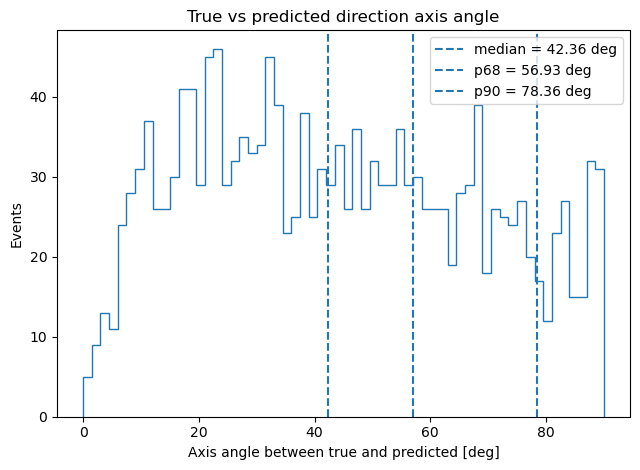

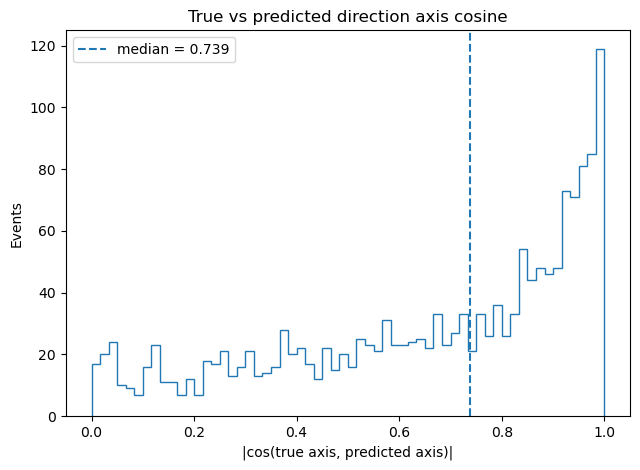

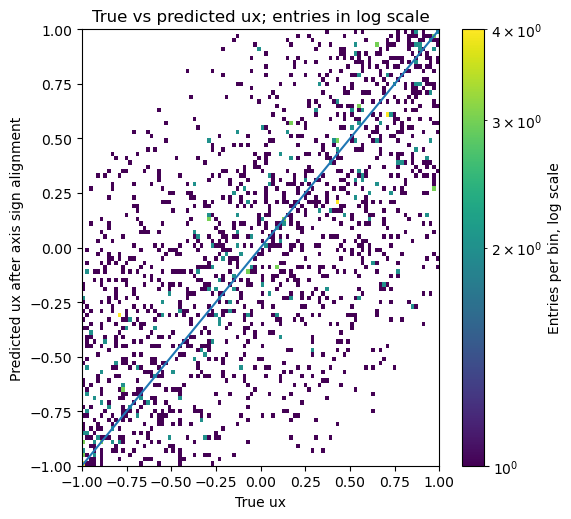

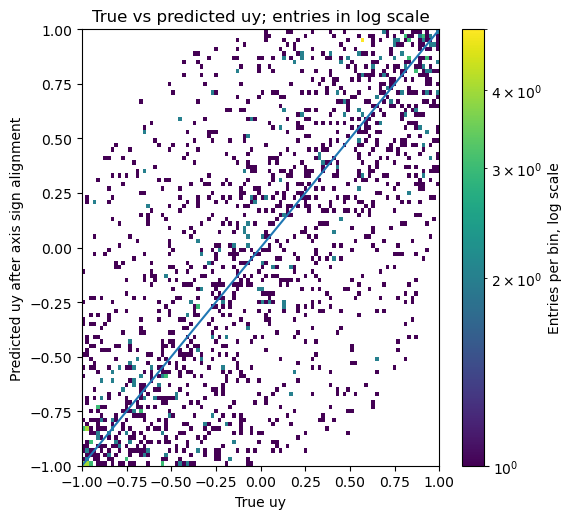

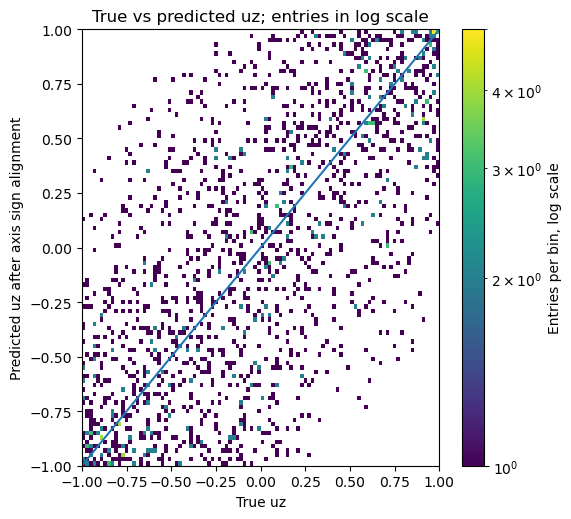

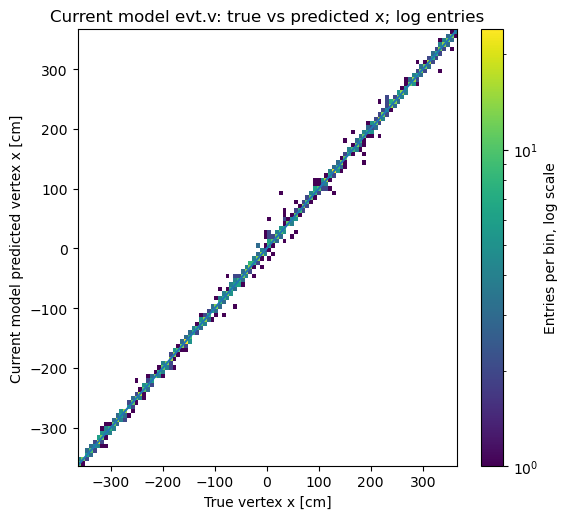

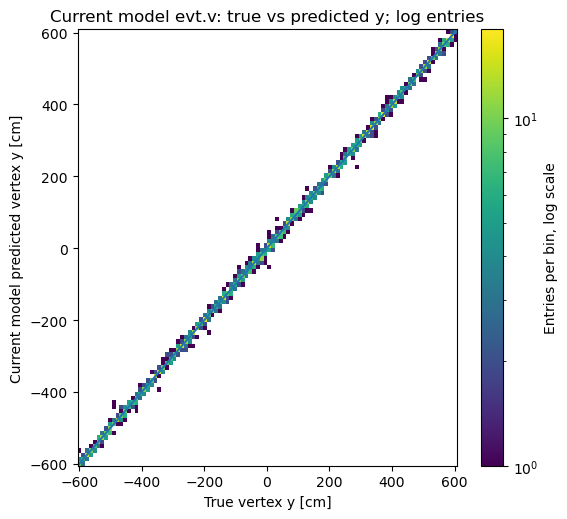

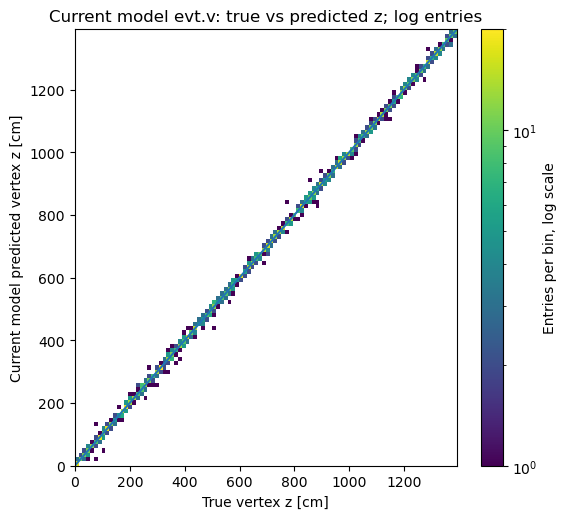

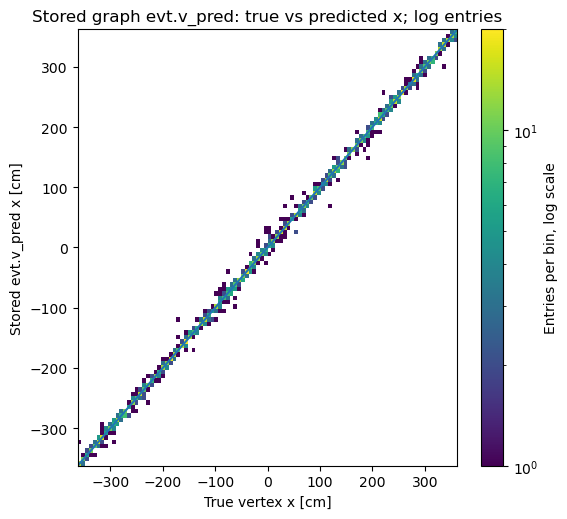

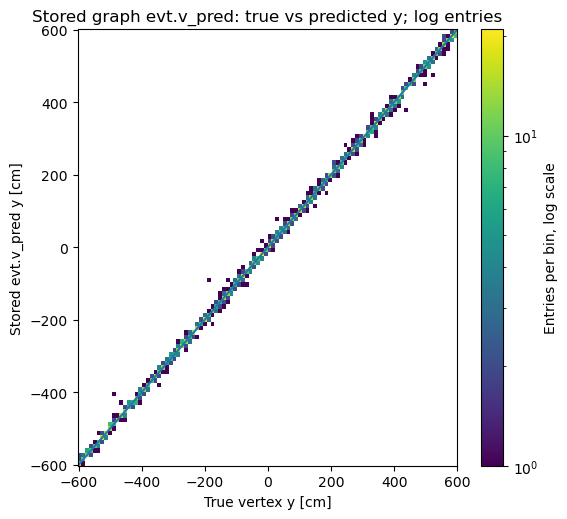

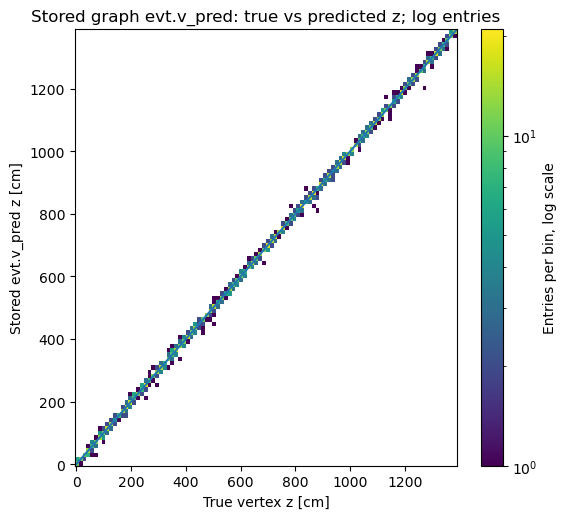

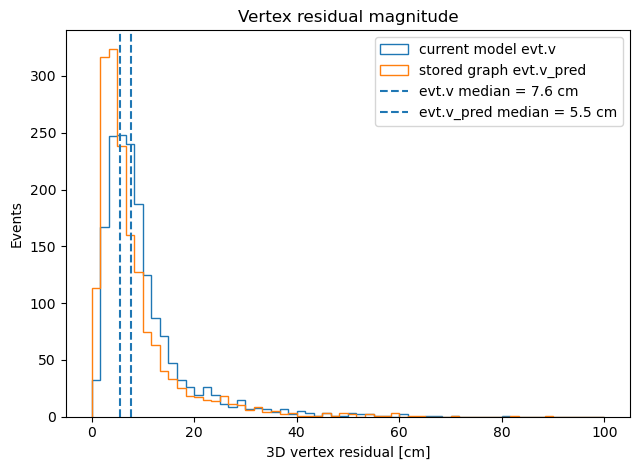

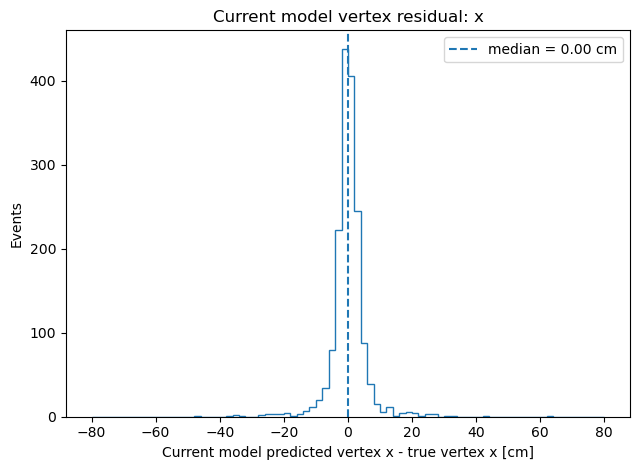

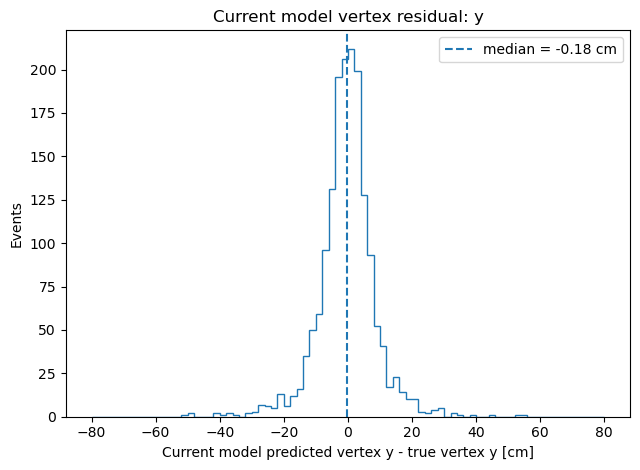

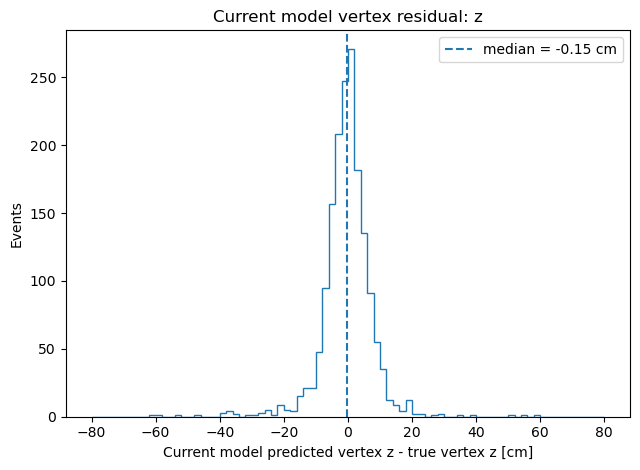

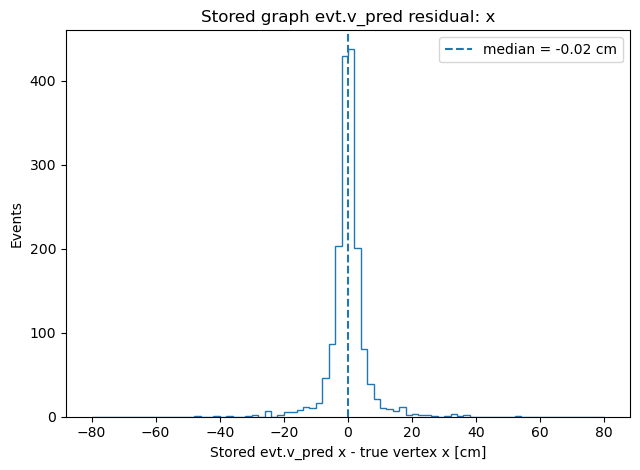

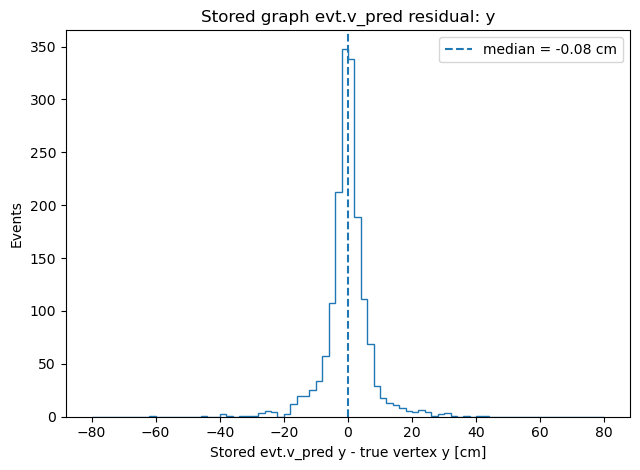

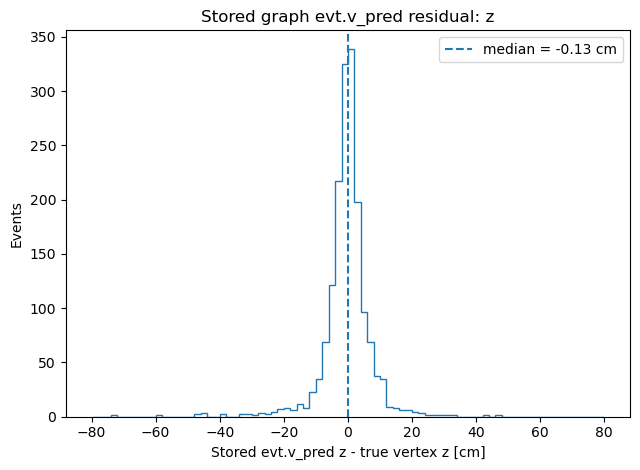

In [2]:
# ============================================================
# Evaluate model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # Fills evt.v = current model vertex prediction
        #       evt.d = current model direction/axis prediction
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            # true vertex from graph
            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),

            # current model predicted vertex
            "pred_vtx": evt.v.detach().float().cpu().numpy(),

            # stored predicted vertex from earlier run, already inside current graph
            "stored_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
pred_vtx = np.concatenate([r["pred_vtx"] for r in rows], axis=0)
stored_vpred = np.concatenate([r["stored_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis comparison because this model was trained with 1 - cos^2.
# u and -u are equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Align predicted axis only for component comparison.
axis_sign = np.where(cos_signed >= 0.0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

# Vertex residuals
pred_vtx_residual = pred_vtx - true_vtx
stored_vpred_residual = stored_vpred - true_vtx

pred_vtx_err = np.linalg.norm(pred_vtx_residual, axis=1)
stored_vpred_err = np.linalg.norm(stored_vpred_residual, axis=1)

# ============================================================
# Summary table
# ============================================================

summary = {
    "N test": len(axis_angle_deg),

    "median axis angle deg": np.median(axis_angle_deg),
    "mean axis angle deg": np.mean(axis_angle_deg),
    "p68 axis angle deg": np.percentile(axis_angle_deg, 68),
    "p90 axis angle deg": np.percentile(axis_angle_deg, 90),
    "median |cos axis|": np.median(axis_cos),
    "mean |cos axis|": np.mean(axis_cos),

    "current evt.v median err cm": np.median(pred_vtx_err),
    "current evt.v mean err cm": np.mean(pred_vtx_err),
    "current evt.v p68 err cm": np.percentile(pred_vtx_err, 68),
    "current evt.v p90 err cm": np.percentile(pred_vtx_err, 90),

    "stored evt.v_pred median err cm": np.median(stored_vpred_err),
    "stored evt.v_pred mean err cm": np.mean(stored_vpred_err),
    "stored evt.v_pred p68 err cm": np.percentile(stored_vpred_err, 68),
    "stored evt.v_pred p90 err cm": np.percentile(stored_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

print("\nMedian angle between true and predicted AXIS:")
print(f"  median axis angle = {np.median(axis_angle_deg):.2f} deg")
print(f"  mean axis angle   = {np.mean(axis_angle_deg):.2f} deg")
print(f"  p68 axis angle    = {np.percentile(axis_angle_deg, 68):.2f} deg")
print(f"  p90 axis angle    = {np.percentile(axis_angle_deg, 90):.2f} deg")

print("\nVertex residuals:")
print(f"  current model evt.v median residual   = {np.median(pred_vtx_err):.2f} cm")
print(f"  stored graph evt.v_pred median residual = {np.median(stored_vpred_err):.2f} cm")

# ============================================================
# Axis angle plots
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.axvline(np.median(axis_angle_deg), linestyle="--", label=f"median = {np.median(axis_angle_deg):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 68), linestyle="--", label=f"p68 = {np.percentile(axis_angle_deg, 68):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 90), linestyle="--", label=f"p90 = {np.percentile(axis_angle_deg, 90):.2f} deg")
plt.xlabel("Axis angle between true and predicted [deg]")
plt.ylabel("Events")
plt.title("True vs predicted direction axis angle")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.axvline(np.median(axis_cos), linestyle="--", label=f"median = {np.median(axis_cos):.3f}")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("True vs predicted direction axis cosine")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Direction component sanity: ux, uy, uz true vs predicted
# x/y axes are linear; entries are log-scaled color
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_axis[:, coord],
        pred_axis_aligned[:, coord],
        bins=100,
        range=[[-1, 1], [-1, 1]],
        norm=LogNorm(),
    )

    plt.plot([-1, 1], [-1, 1], linewidth=1.5)
    plt.xlabel(f"True u{label}")
    plt.ylabel(f"Predicted u{label} after axis sign alignment")
    plt.title(f"True vs predicted u{label}; entries in log scale")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()

# ============================================================
# Current model vertex: true vs predicted evt.v
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), pred_vtx[:, coord].min())
    hi = max(true_vtx[:, coord].max(), pred_vtx[:, coord].max())

    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_vtx[:, coord],
        pred_vtx[:, coord],
        bins=100,
        range=[[lo, hi], [lo, hi]],
        norm=LogNorm(),
    )

    plt.plot([lo, hi], [lo, hi], linewidth=1.5)
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Current model predicted vertex {label} [cm]")
    plt.title(f"Current model evt.v: true vs predicted {label}; log entries")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()

# ============================================================
# Stored predicted vertex sanity check: true vs stored evt.v_pred
# This checks the v_pred already written into the graph file.
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), stored_vpred[:, coord].min())
    hi = max(true_vtx[:, coord].max(), stored_vpred[:, coord].max())

    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_vtx[:, coord],
        stored_vpred[:, coord],
        bins=100,
        range=[[lo, hi], [lo, hi]],
        norm=LogNorm(),
    )

    plt.plot([lo, hi], [lo, hi], linewidth=1.5)
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Stored evt.v_pred {label} [cm]")
    plt.title(f"Stored graph evt.v_pred: true vs predicted {label}; log entries")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()

# ============================================================
# Vertex residual magnitude comparison
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(pred_vtx_err, bins=60, range=(0, 100), histtype="step", label="current model evt.v")
plt.hist(stored_vpred_err, bins=60, range=(0, 100), histtype="step", label="stored graph evt.v_pred")
plt.axvline(np.median(pred_vtx_err), linestyle="--", label=f"evt.v median = {np.median(pred_vtx_err):.1f} cm")
plt.axvline(np.median(stored_vpred_err), linestyle="--", label=f"evt.v_pred median = {np.median(stored_vpred_err):.1f} cm")
plt.xlabel("3D vertex residual [cm]")
plt.ylabel("Events")
plt.title("Vertex residual magnitude")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Vertex residual components
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = pred_vtx_residual[:, coord]

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-80, 80), histtype="step")
    plt.axvline(np.median(residual), linestyle="--", label=f"median = {np.median(residual):.2f} cm")
    plt.xlabel(f"Current model predicted vertex {label} - true vertex {label} [cm]")
    plt.ylabel("Events")
    plt.title(f"Current model vertex residual: {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = stored_vpred_residual[:, coord]

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-80, 80), histtype="step")
    plt.axvline(np.median(residual), linestyle="--", label=f"median = {np.median(residual):.2f} cm")
    plt.xlabel(f"Stored evt.v_pred {label} - true vertex {label} [cm]")
    plt.ylabel("Events")
    plt.title(f"Stored graph evt.v_pred residual: {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

,x residual mean cm,x residual std cm,x residual median cm,y residual mean cm,y residual std cm,y residual median cm,z residual mean cm,z residual std cm,z residual median cm
0,0.0876,5.676,0.0039,-0.3653,9.0128,-0.1785,-0.4269,8.0117,-0.1529


Current model vertex residual std wrt truth:
  std(pred_x - true_x) = 5.68 cm
  std(pred_y - true_y) = 9.01 cm
  std(pred_z - true_z) = 8.01 cm


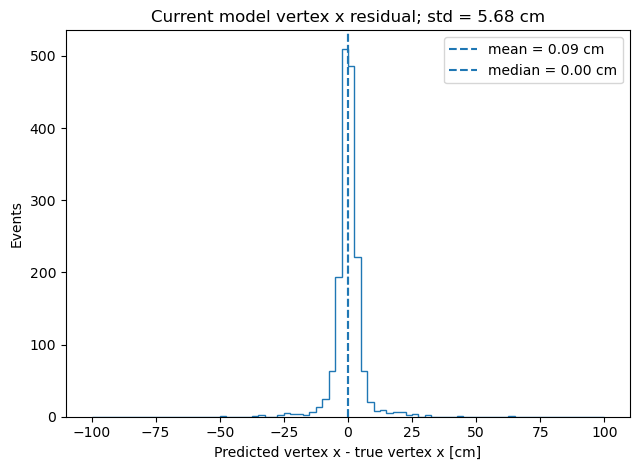

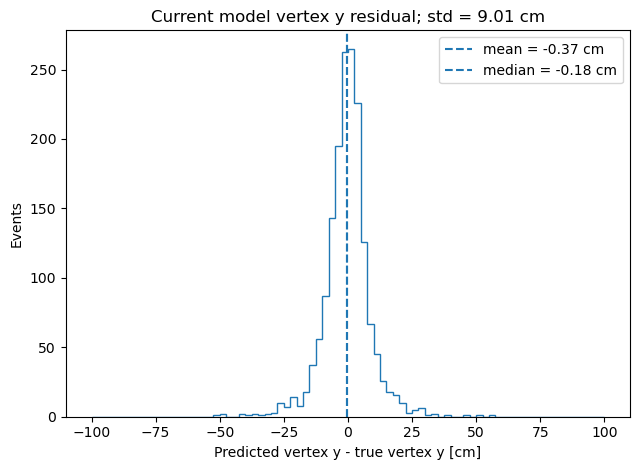

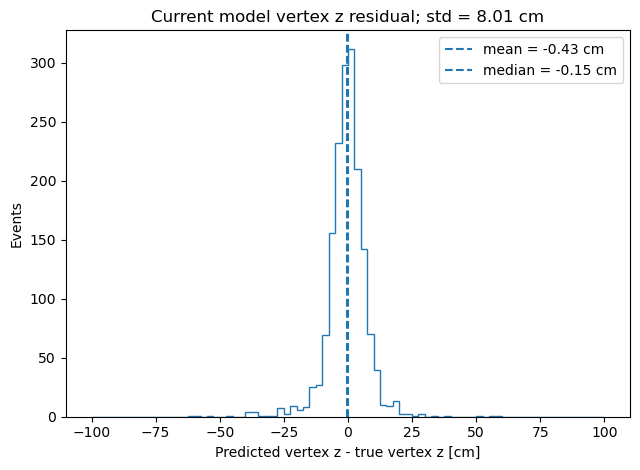

In [3]:
# ============================================================
# Cell 3 — current model vertex residual std wrt truth
# ============================================================

# Uses arrays already made in Cell 2:
# true_vtx, pred_vtx, pred_vtx_residual = pred_vtx - true_vtx

pred_vtx_residual = pred_vtx - true_vtx

vertex_std = {
    "x residual mean cm": np.mean(pred_vtx_residual[:, 0]),
    "x residual std cm": np.std(pred_vtx_residual[:, 0]),
    "x residual median cm": np.median(pred_vtx_residual[:, 0]),

    "y residual mean cm": np.mean(pred_vtx_residual[:, 1]),
    "y residual std cm": np.std(pred_vtx_residual[:, 1]),
    "y residual median cm": np.median(pred_vtx_residual[:, 1]),

    "z residual mean cm": np.mean(pred_vtx_residual[:, 2]),
    "z residual std cm": np.std(pred_vtx_residual[:, 2]),
    "z residual median cm": np.median(pred_vtx_residual[:, 2]),
}

display(pd.DataFrame([vertex_std]).round(4))

print("Current model vertex residual std wrt truth:")
print(f"  std(pred_x - true_x) = {np.std(pred_vtx_residual[:, 0]):.2f} cm")
print(f"  std(pred_y - true_y) = {np.std(pred_vtx_residual[:, 1]):.2f} cm")
print(f"  std(pred_z - true_z) = {np.std(pred_vtx_residual[:, 2]):.2f} cm")

# Optional residual histograms with std labels
for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = pred_vtx_residual[:, coord]
    mu = np.mean(residual)
    sigma = np.std(residual)
    med = np.median(residual)

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-100, 100), histtype="step")
    plt.axvline(mu, linestyle="--", label=f"mean = {mu:.2f} cm")
    plt.axvline(med, linestyle="--", label=f"median = {med:.2f} cm")
    plt.xlabel(f"Predicted vertex {label} - true vertex {label} [cm]")
    plt.ylabel("Events")
    plt.title(f"Current model vertex {label} residual; std = {sigma:.2f} cm")
    plt.legend()
    plt.tight_layout()
    plt.show()